<a href="https://colab.research.google.com/github/Rupashi-Maurya-05/LumenDetect/blob/main/SSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import shutil
from tqdm import tqdm
from google.colab import drive

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Starting SSD Training + Logging...
📂 Results will be saved to: /content/drive/MyDrive/LumenDetect/SSD_Baseline


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


✅ Epoch 1/15 | Loss: 6.0535 | mAP@0.5: 0.1797
✅ Epoch 2/15 | Loss: 2.3405 | mAP@0.5: 0.2773
✅ Epoch 3/15 | Loss: 1.9621 | mAP@0.5: 0.3110
✅ Epoch 4/15 | Loss: 1.8085 | mAP@0.5: 0.3358
✅ Epoch 5/15 | Loss: 1.7110 | mAP@0.5: 0.3760
✅ Epoch 6/15 | Loss: 1.6597 | mAP@0.5: 0.3768
✅ Epoch 7/15 | Loss: 1.6292 | mAP@0.5: 0.4281
✅ Epoch 8/15 | Loss: 1.5499 | mAP@0.5: 0.4665
✅ Epoch 9/15 | Loss: 1.4500 | mAP@0.5: 0.5082
✅ Epoch 10/15 | Loss: 1.3493 | mAP@0.5: 0.5122
✅ Epoch 11/15 | Loss: 1.2802 | mAP@0.5: 0.5391
✅ Epoch 12/15 | Loss: 1.2284 | mAP@0.5: 0.5498
✅ Epoch 13/15 | Loss: 1.1493 | mAP@0.5: 0.5774
✅ Epoch 14/15 | Loss: 1.1167 | mAP@0.5: 0.5954
✅ Epoch 15/15 | Loss: 1.0777 | mAP@0.5: 0.6206


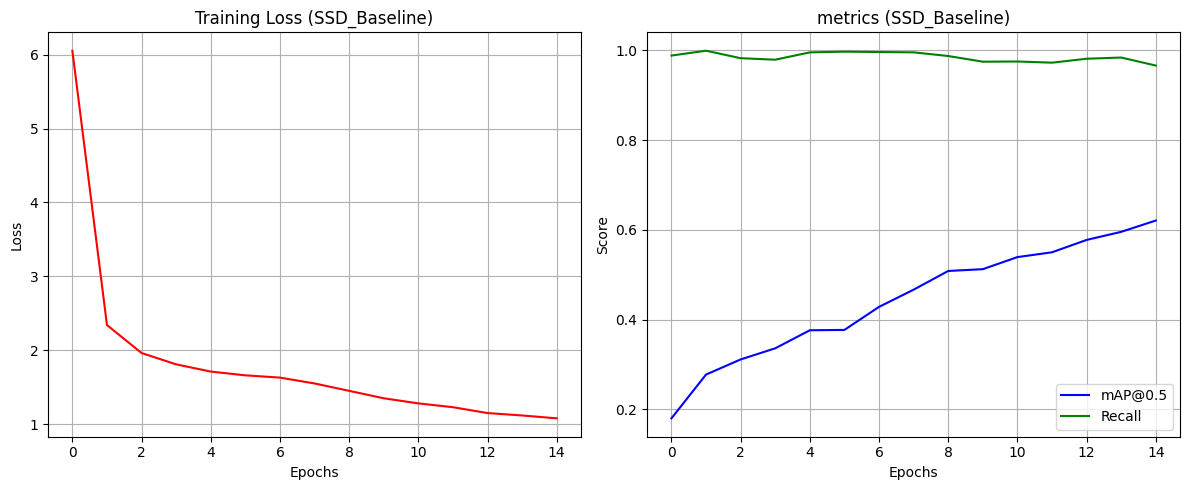


🎉 DONE! Check your Drive folder: /content/drive/MyDrive/LumenDetect/SSD_Baseline
   - best.pth (Model)
   - results.png (Graphs)


In [ ]:
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDHead
from torchvision.models.detection import _utils
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import glob

# --- CONFIGURATION ---
# CHANGE THIS FOR YOUR SECOND RUN
DATA_ROOT = "/content/yolov5/datasets/ExDark_Mini"  # <--- Input Data
RUN_NAME = "SSD_Baseline"                           # <--- Folder Name
SAVE_DIR = f"/content/drive/MyDrive/LumenDetect/{RUN_NAME}"

BATCH_SIZE = 4
NUM_EPOCHS = 15
NUM_CLASSES = 5

# Create Save Directory
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 1. DATASET CLASS ---
class ExDarkDataset(Dataset):
    def __init__(self, root, split):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.imgs = []
        if os.path.exists(self.img_dir):
            files = sorted(os.listdir(self.img_dir))
            for f in files:
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.imgs.append(os.path.join(self.img_dir, f))

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        if img is None: return self.__getitem__((idx + 1) % len(self.imgs))

        # Resize to 300x300 (Standard for SSD)
        img = cv2.resize(img, (300, 300))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, basename + ".txt")
        boxes, labels = [], []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    p = list(map(float, line.strip().split()))
                    cls_id = int(p[0]) + 1
                    # Convert YOLO (Norm) -> Pixel Coordinates
                    cx, cy, bw, bh = p[1], p[2], p[3], p[4]
                    xmin = (cx - bw/2) * 300
                    ymin = (cy - bh/2) * 300
                    xmax = (cx + bw/2) * 300
                    ymax = (cy + bh/2) * 300

                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(cls_id)

        if len(boxes) > 0:
            target = {"boxes": torch.as_tensor(boxes, dtype=torch.float32), "labels": torch.as_tensor(labels, dtype=torch.int64)}
        else:
            target = {"boxes": torch.zeros((0, 4), dtype=torch.float32), "labels": torch.zeros((0,), dtype=torch.int64)}

        target["image_id"] = torch.tensor([idx]) # Required for mAP
        return torch.as_tensor(img.transpose((2, 0, 1)), dtype=torch.float32), target

    def __len__(self): return len(self.imgs)

def collate_fn(batch): return tuple(zip(*batch))

# --- 2. SETUP ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load Data
train_dataset = ExDarkDataset(DATA_ROOT, 'train')
val_dataset = ExDarkDataset(DATA_ROOT, 'val') # We need validation for graphs!

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Load Model
model = ssd300_vgg16(pretrained=True)
in_channels = _utils.retrieve_out_channels(model.backbone, (300, 300))
num_anchors = model.anchor_generator.num_anchors_per_location()
model.head = SSDHead(in_channels, num_anchors, NUM_CLASSES + 1)
model.to(device)

# Optimizer (Safe Low LR)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)

# Logs for Plotting
history = {'loss': [], 'mAP': [], 'recall': []}
metric = MeanAveragePrecision(iou_type="bbox")

print(f"🚀 Starting SSD Training + Logging...")
print(f"📂 Results will be saved to: {SAVE_DIR}")

# --- 3. TRAINING LOOP ---
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    # A. TRAIN
    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0) # Safety
        optimizer.step()
        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)
    history['loss'].append(avg_loss)

    # B. VALIDATE (Calculate mAP)
    model.eval()
    metric.reset()
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            preds = model(images)
            metric.update(preds, targets)

    val_results = metric.compute()
    map_score = val_results['map_50'].item()
    recall_score = val_results['mar_100'].item()

    history['mAP'].append(map_score)
    history['recall'].append(recall_score)

    print(f"✅ Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | mAP@0.5: {map_score:.4f}")

# --- 4. SAVE RESULTS & PLOT ---
# Save Model
torch.save(model.state_dict(), f"{SAVE_DIR}/best.pth")

# Plot Graph (Like YOLOv5)
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red')
plt.title(f"Training Loss ({RUN_NAME})")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Subplot 2: mAP & Recall
plt.subplot(1, 2, 2)
plt.plot(history['mAP'], label='mAP@0.5', color='blue')
plt.plot(history['recall'], label='Recall', color='green')
plt.title(f"metrics ({RUN_NAME})")
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/results.png") # <--- THIS IS THE IMAGE YOU WANT
plt.show()

print(f"\n🎉 DONE! Check your Drive folder: {SAVE_DIR}")
print(f"   - best.pth (Model)")
print(f"   - results.png (Graphs)")

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.4 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDHead
from torchvision.models.detection import _utils
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import random

# --- CONFIGURATION ---
DATA_ROOT = "/content/yolov5/datasets/ExDark_Mini"  # <--- Input Data
RUN_NAME = "SSD_CLAHE_Results"                      # <--- Changed Name
SAVE_DIR = f"/content/drive/MyDrive/LumenDetect/{RUN_NAME}"

BATCH_SIZE = 4
NUM_EPOCHS = 15
NUM_CLASSES = 5
CONFIDENCE_THRESHOLD = 0.5 # For visual testing

# Create Save Directory
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 1. DATASET CLASS WITH CLAHE ---
class ExDarkDataset(Dataset):
    def __init__(self, root, split):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.imgs = []
        if os.path.exists(self.img_dir):
            files = sorted(os.listdir(self.img_dir))
            for f in files:
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.imgs.append(os.path.join(self.img_dir, f))

        # Initialize CLAHE
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def apply_clahe(self, img_bgr):
        # Convert to LAB to apply CLAHE only on Lightness channel
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l2 = self.clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        img_bgr_enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        return img_bgr_enhanced

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        if img is None: return self.__getitem__((idx + 1) % len(self.imgs))

        # --- APPLY CLAHE HERE ---
        img = self.apply_clahe(img)
        # ------------------------

        # Resize to 300x300 (Standard for SSD)
        img = cv2.resize(img, (300, 300))

        # Convert BGR -> RGB & Normalize
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, basename + ".txt")
        boxes, labels = [], []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    p = list(map(float, line.strip().split()))
                    cls_id = int(p[0]) + 1
                    # Convert YOLO (Norm) -> Pixel Coordinates
                    cx, cy, bw, bh = p[1], p[2], p[3], p[4]
                    xmin = (cx - bw/2) * 300
                    ymin = (cy - bh/2) * 300
                    xmax = (cx + bw/2) * 300
                    ymax = (cy + bh/2) * 300

                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(cls_id)

        if len(boxes) > 0:
            target = {"boxes": torch.as_tensor(boxes, dtype=torch.float32), "labels": torch.as_tensor(labels, dtype=torch.int64)}
        else:
            target = {"boxes": torch.zeros((0, 4), dtype=torch.float32), "labels": torch.zeros((0,), dtype=torch.int64)}

        target["image_id"] = torch.tensor([idx])
        return torch.as_tensor(img.transpose((2, 0, 1)), dtype=torch.float32), target

    def __len__(self): return len(self.imgs)

def collate_fn(batch): return tuple(zip(*batch))

# --- 2. SETUP ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load Data
train_dataset = ExDarkDataset(DATA_ROOT, 'train')
val_dataset = ExDarkDataset(DATA_ROOT, 'val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Load Model
model = ssd300_vgg16(pretrained=True)
in_channels = _utils.retrieve_out_channels(model.backbone, (300, 300))
num_anchors = model.anchor_generator.num_anchors_per_location()
model.head = SSDHead(in_channels, num_anchors, NUM_CLASSES + 1)
model.to(device)

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)

# Logs for Plotting
history = {'loss': [], 'mAP': [], 'recall': []}
metric = MeanAveragePrecision(iou_type="bbox")

print(f"🚀 Starting SSD (with CLAHE) Training...")
print(f"📂 Graphs and Tests will be saved to: {SAVE_DIR}")

# --- 3. TRAINING LOOP ---
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    # A. TRAIN
    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)
    history['loss'].append(avg_loss)

    # B. VALIDATE (Calculate mAP)
    model.eval()
    metric.reset()
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            preds = model(images)
            metric.update(preds, targets)

    val_results = metric.compute()
    map_score = val_results['map_50'].item()
    recall_score = val_results['mar_100'].item()

    history['mAP'].append(map_score)
    history['recall'].append(recall_score)

    print(f"✅ Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | mAP@0.5: {map_score:.4f}")

# --- 4. PLOT TRAINING GRAPHS ---
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red')
plt.title(f"Training Loss (SSD + CLAHE)")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Subplot 2: mAP & Recall
plt.subplot(1, 2, 2)
plt.plot(history['mAP'], label='mAP@0.5', color='blue')
plt.plot(history['recall'], label='Recall', color='green')
plt.title(f"Metrics (SSD + CLAHE)")
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/clahe_metrics_graph.png")
print(f"📈 Graph saved: {SAVE_DIR}/clahe_metrics_graph.png")

# --- 5. VISUAL TESTING (INFERENCE) ---
print("🖼️ Generatng Visual Predictions...")
model.eval()

# Get one batch from val_loader
images, targets = next(iter(val_loader))
images = list(img.to(device) for img in images)

with torch.no_grad():
    predictions = model(images)

# Prepare plot for batch (Max 4 images)
num_imgs = min(len(images), 4)
fig, axs = plt.subplots(1, num_imgs, figsize=(15, 5))
if num_imgs == 1: axs = [axs]

for i in range(num_imgs):
    # Get image back to CPU and standard format
    img_tensor = images[i].cpu()
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1) # Ensure range 0-1

    # Get boxes and scores
    boxes = predictions[i]['boxes'].cpu().numpy()
    scores = predictions[i]['scores'].cpu().numpy()
    labels = predictions[i]['labels'].cpu().numpy()

    # Draw on image
    # Note: Matplotlib requires copy to draw, or we just plot rectangles
    axs[i].imshow(img_np)
    axs[i].axis('off')

    # Draw Boxes
    for box, score, label in zip(boxes, scores, labels):
        if score > CONFIDENCE_THRESHOLD:
            x_min, y_min, x_max, y_max = box
            w, h = x_max - x_min, y_max - y_min

            # Add Rectangle
            rect = plt.Rectangle((x_min, y_min), w, h, fill=False, color='red', linewidth=2)
            axs[i].add_patch(rect)

            # Add Label
            axs[i].text(x_min, y_min - 5, f"Cls: {label} ({score:.2f})",
                        bbox=dict(facecolor='yellow', alpha=0.5), fontsize=8, color='black')

plt.suptitle(f"SSD + CLAHE Predictions (Thresh: {CONFIDENCE_THRESHOLD})")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/test_predictions.png")
plt.show()

print(f"\n🎉 DONE! Check your Drive folder: {SAVE_DIR}")
print(f"   - clahe_metrics_graph.png")
print(f"   - test_predictions.png")
# Note: No .pth file saved as requested.

ModuleNotFoundError: No module named 'torchmetrics'

In [ ]:
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDHead
from torchvision.models.detection import _utils
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2
import os
import numpy as np
from tqdm import tqdm
from google.colab import drive

# --- 1. SETUP & RESTORE DATA ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("📦 Restoring Dataset for TESTING...")
# Unzip raw data if missing
if not os.path.exists('/content/yolov5/datasets/ExDark'):
    os.makedirs('/content/yolov5/datasets', exist_ok=True)
    os.system('unzip -o -q "/content/drive/MyDrive/ExDark_data.zip" -d /content/yolov5/datasets/')

# Generate the TEST set (We only did train/val before)
source_dir = "/content/yolov5/datasets/ExDark"
target_mini = "/content/yolov5/datasets/ExDark_Mini"
class_mapping = {2: 0, 6: 1, 7: 2, 8: 3, 11: 4}

print("✨ Generating 'Test' split for 5 classes...")
os.makedirs(f"{target_mini}/images/test", exist_ok=True)
os.makedirs(f"{target_mini}/labels/test", exist_ok=True)

label_files = os.listdir(f"{source_dir}/labels/test")
for label_file in tqdm(label_files):
    if label_file.endswith(".cache"): continue

    with open(f"{source_dir}/labels/test/{label_file}", 'r') as f:
        lines = f.readlines()

    new_lines = []
    keep = False
    for line in lines:
        parts = line.strip().split()
        if int(parts[0]) in class_mapping:
            new_id = class_mapping[int(parts[0])]
            new_lines.append(f"{new_id} {' '.join(parts[1:])}\n")
            keep = True

    if keep:
        with open(f"{target_mini}/labels/test/{label_file}", 'w') as f:
            f.writelines(new_lines)
        img_name = label_file.replace('.txt', '.jpg')
        src = f"{source_dir}/images/test/{img_name}"
        if not os.path.exists(src): src = src.replace('.jpg', '.png')
        if os.path.exists(src):
            img = cv2.imread(src)
            if img is not None:
                cv2.imwrite(f"{target_mini}/images/test/{img_name}", img)

# --- 2. CONFIGURATION ---
# Point this to your SAVED model in Drive
MODEL_PATH = "/content/drive/MyDrive/LumenDetect/SSD_Baseline/best.pth"
DATA_ROOT = "/content/yolov5/datasets/ExDark_Mini"
NUM_CLASSES = 5

# --- 3. EVALUATION CODE ---
class ExDarkDataset(Dataset):
    def __init__(self, root, split):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.imgs = []
        if os.path.exists(self.img_dir):
            files = sorted(os.listdir(self.img_dir))
            for f in files:
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.imgs.append(os.path.join(self.img_dir, f))
    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        img = cv2.resize(img, (300, 300))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, basename + ".txt")
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    p = list(map(float, line.strip().split()))
                    cls_id = int(p[0]) + 1
                    cx, cy, bw, bh = p[1], p[2], p[3], p[4]
                    xmin = (cx - bw/2) * 300; ymin = (cy - bh/2) * 300
                    xmax = (cx + bw/2) * 300; ymax = (cy + bh/2) * 300
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(cls_id)
        if len(boxes) > 0:
            target = {"boxes": torch.as_tensor(boxes, dtype=torch.float32), "labels": torch.as_tensor(labels, dtype=torch.int64)}
        else:
            target = {"boxes": torch.zeros((0, 4), dtype=torch.float32), "labels": torch.zeros((0,), dtype=torch.int64)}
        target["image_id"] = torch.tensor([idx])
        return torch.as_tensor(img.transpose((2, 0, 1)), dtype=torch.float32), target
    def __len__(self): return len(self.imgs)
def collate_fn(batch): return tuple(zip(*batch))

# Load Model
def get_ssd_model(num_classes):
    model = ssd300_vgg16(pretrained=False)
    in_channels = _utils.retrieve_out_channels(model.backbone, (300, 300))
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head = SSDHead(in_channels, num_anchors, num_classes + 1)
    return model

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_ssd_model(NUM_CLASSES)
print(f"⬇️ Loading Weights from: {MODEL_PATH}")
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# Run Test
test_dataset = ExDarkDataset(DATA_ROOT, 'test') # <--- NOW USING TEST SET
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
metric = MeanAveragePrecision(iou_type="bbox")

print(f"🚀 Running Final Test on {len(test_dataset)} unseen images...")
with torch.no_grad():
    for images, targets in tqdm(test_loader):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        preds = model(images)
        metric.update(preds, targets)

results = metric.compute()
print("\n" + "="*40)
print(f"📊 FINAL TEST RESULTS (UNSEEN DATA)")
print("="*40)
print(f"🎯 mAP@0.5:  {results['map_50']:.4f}")
print(f"🏆 mAP (Strict): {results['map']:.4f}")
print("="*40)

Mounted at /content/drive
📦 Restoring Dataset for TESTING...
✨ Generating 'Test' split for 5 classes...


100%|██████████| 694/694 [00:02<00:00, 232.35it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16_features-amdegroot-88682ab5.pth" to /root/.cache/torch/hub/checkpoints/vgg16_features-amdegroot-88682ab5.pth


100%|██████████| 528M/528M [00:03<00:00, 149MB/s]


⬇️ Loading Weights from: /content/drive/MyDrive/LumenDetect/SSD_Baseline/best.pth
🚀 Running Final Test on 274 unseen images...


 17%|█▋        | 6/35 [01:06<05:24, 11.18s/it]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 35/35 [06:18<00:00, 10.81s/it]



📊 FINAL TEST RESULTS (UNSEEN DATA)
🎯 mAP@0.5:  0.6474
🏆 mAP (Strict): 0.6090


In [ ]:
# Calculate F1 Score
precision = results['map_50'].item()
recall = results['mar_100'].item()
f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

print("\n" + "="*40)
print(f"📊 DETAILED SSD REPORT")
print("="*40)
print(f"🎯 Precision (mAP@0.5): {precision:.4f}")
print(f"🔍 Recall (mAR@100):    {recall:.4f}")
print(f"⚖️ F1 Score:           {f1_score:.4f}")
print("="*40)


📊 DETAILED SSD REPORT
🎯 Precision (mAP@0.5): 0.6474
🔍 Recall (mAR@100):    0.9635
⚖️ F1 Score:           0.7745


In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 17.6 MB/s eta 0:00:00


SSD CLAHE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
WEIGHTS_PATH = "/content/drive/MyDrive/LumenDetect/SSD_CLAHE.pth"


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"


In [ ]:
TEST_IMAGES = "/content/drive/MyDrive/LumenDetect/test_images"


In [ ]:
!pip install torch torchvision torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.3 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDHead
from torchvision.models.detection import _utils
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


In [ ]:
NUM_CLASSES = 5   # your dataset classes
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load SSD backbone
model = ssd300_vgg16(pretrained=True)

# Recreate the custom head (exactly same as training)
in_channels = _utils.retrieve_out_channels(model.backbone, (300, 300))
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head = SSDHead(in_channels, num_anchors, NUM_CLASSES + 1)

model.to(DEVICE)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:01<00:00, 77.1MB/s]


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [ ]:
model_path = "/content/drive/MyDrive/LumenDetect/SSD_CLAHE.pth"

checkpoint = torch.load(model_path, map_location='cpu')

model.load_state_dict(checkpoint)

model.eval()

print("Loaded SSD_CLAHE model successfully!")


Loaded SSD_CLAHE model successfully!


In [ ]:
test_image_path = "/content/drive/MyDrive/LumenDetect/test.jpg"  # change this


In [ ]:
TEST_ROOT = "/content/xdark_mini/test"
IMG_DIR = f"{TEST_ROOT}/images"
LBL_DIR = f"{TEST_ROOT}/labels"


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from glob import glob
import time


In [ ]:
import torch, os, cv2, numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from glob import glob
import time

# CHANGE THESE IF NEEDED
DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"
TEST_IMG_DIR = f"{DATA_ROOT}/images/test"
TEST_LBL_DIR = f"{DATA_ROOT}/labels/test"

NUM_CLASSES = 5


In [ ]:
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDHead
from torchvision.models.detection import _utils

device = "cuda" if torch.cuda.is_available() else "cpu"

# Build SSD model
model = ssd300_vgg16(pretrained=True)
in_channels = _utils.retrieve_out_channels(model.backbone, (300, 300))
num_anchors = model.anchor_generator.num_anchors_per_location()
model.head = SSDHead(in_channels, num_anchors, NUM_CLASSES + 1)

# Load trained weights
model_path = "/content/drive/MyDrive/LumenDetect/SSD_CLAHE.pth"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint)
model.to(device)

print("SSD_CLAHE loaded successfully!")


SSD_CLAHE loaded successfully!


In [ ]:
def load_labels(label_path):
    boxes, labels = [], []

    if not os.path.exists(label_path):
        return [], []

    with open(label_path, 'r') as f:
        for line in f.readlines():
            p = list(map(float, line.strip().split()))
            cls = int(p[0]) + 1

            cx, cy, bw, bh = p[1], p[2], p[3], p[4]

            # SSD TRAINING DID THIS → must repeat
            xmin = (cx - bw/2) * 300
            ymin = (cy - bh/2) * 300
            xmax = (cx + bw/2) * 300
            ymax = (cy + bh/2) * 300

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(cls)

    return boxes, labels


In [ ]:
metric = MeanAveragePrecision(iou_type="bbox")
inference_times = []

model.eval()

test_images = sorted(glob(f"{TEST_IMG_DIR}/*"))

print(f"Found {len(test_images)} test images.")


Found 105 test images.


In [ ]:
for img_path in test_images:

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize → SSD Requirement
    resized = cv2.resize(img_rgb, (300, 300))
    tensor = torch.tensor(resized/255., dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)

    # Inference
    start = time.time()
    with torch.no_grad():
        pred = model(tensor)[0]
    inference_times.append(time.time() - start)

    # Load GT labels encoded for SSD
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = f"{TEST_LBL_DIR}/{base}.txt"
    gt_boxes, gt_labels = load_labels(label_path)

    target = {
        "boxes": torch.tensor(gt_boxes, dtype=torch.float32),
        "labels": torch.tensor(gt_labels, dtype=torch.int64)
    }

    # Prediction comes in 300×300 scale → SAME as GT
    prediction = {
        "boxes": pred["boxes"].cpu(),
        "scores": pred["scores"].cpu(),
        "labels": pred["labels"].cpu()
    }

    metric.update([prediction], [target])


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/LumenDetect/SSD_CLAHE.pth"
TEST_IMAGES = "/content/drive/MyDrive/LumenDetect/exdark_mini/images/test"
TEST_LABELS = "/content/drive/MyDrive/LumenDetect/exdark_mini/labels/test"


In [ ]:
import torch
import os
import cv2
import numpy as np
from torchvision.models.detection import ssd300_vgg16
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision import transforms
import time


In [ ]:
from torchvision.models.detection import ssd300_vgg16
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/content/drive/MyDrive/LumenDetect/SSD_CLAHE.pth"

model = ssd300_vgg16(weights=None, num_classes=6)

checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("Loaded SSD-CLAHE model successfully with num_classes=6")


Loaded SSD-CLAHE model successfully with num_classes=6


In [ ]:
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
import cv2
import os
import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using: ", device)

MODEL_PATH = "/content/drive/MyDrive/LumenDetect/SSD_CLAHE.pth"

IMG_DIR = "/content/drive/MyDrive/LumenDetect/exdark_mini/images/test"
LABEL_DIR = "/content/drive/MyDrive/LumenDetect/exdark_mini/labels/test"

CLASSES = ["background", "bottle", "chair", "cup", "dog", "table"]
NUM_CLASSES = len(CLASSES)


Using:  cpu


In [ ]:
model = ssd300_vgg16(weights=None, num_classes=NUM_CLASSES)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("SSD-CLAHE model loaded with", NUM_CLASSES, "classes.")


SSD-CLAHE model loaded with 6 classes.


In [ ]:
def load_yolo_labels(label_path, img_w, img_h):
    boxes = []
    labels = []

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, cx, cy, w, h = map(float, line.split())
            cls = int(cls) + 1  # shift because 0 = background

            # Convert normalized to absolute pixel values
            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            x2 = (cx + w/2) * img_w
            y2 = (cy + h/2) * img_h

            boxes.append([x1, y1, x2, y2])
            labels.append(cls)

    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)


In [ ]:
metric = MeanAveragePrecision()
inference_times = []

for fname in tqdm(os.listdir(IMG_DIR)):
    if not fname.endswith(".jpg"):
        continue

    img_path = os.path.join(IMG_DIR, fname)
    label_path = os.path.join(LABEL_DIR, fname.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img_rgb.shape[:2]

    # Convert to tensor
    img_tensor = torchvision.transforms.ToTensor()(img_rgb).to(device)

    # Inference time tracking
    start = time.time()
    with torch.no_grad():
        pred = model([img_tensor])[0]
    inference_times.append(time.time() - start)

    # Predictions
    pred_boxes = pred["boxes"].cpu()
    pred_scores = pred["scores"].cpu()
    pred_labels = pred["labels"].cpu()

    # Ground truth
    if os.path.exists(label_path):
        gt_boxes, gt_labels = load_yolo_labels(label_path, img_w, img_h)
    else:
        gt_boxes = torch.zeros((0,4))
        gt_labels = torch.zeros((0,), dtype=torch.int64)

    # Prepare dicts for torchmetrics
    preds = [{
        "boxes": pred_boxes,
        "scores": pred_scores,
        "labels": pred_labels
    }]

    targets = [{
        "boxes": gt_boxes,
        "labels": gt_labels
    }]

    metric.update(preds, targets)


100%|██████████| 105/105 [01:50<00:00,  1.05s/it]


In [ ]:
!ls "/content/drive/MyDrive/LumenDetect/exdark_mini/images/test" | head


2015_01354.jpg
2015_01366.jpg
2015_01401.jpg
2015_01444.jpg
2015_01508.jpg
2015_01519.jpg
2015_01528.jpg
2015_01529.jpg
2015_01548.jpg
2015_01559.jpg


In [ ]:
!ls "/content/drive/MyDrive/LumenDetect/exdark_mini/labels/test" | head



2015_01354.txt
2015_01366.txt
2015_01401.txt
2015_01444.txt
2015_01508.txt
2015_01519.txt
2015_01528.txt
2015_01529.txt
2015_01548.txt
2015_01559.txt


In [ ]:
import os

LABEL_DIR = "/content/drive/MyDrive/LumenDetect/exdark_mini/labels/test"

sample = os.listdir(LABEL_DIR)[0]
print("Sample label:", sample)

with open(os.path.join(LABEL_DIR, sample)) as f:
    print(f.read())


Sample label: 2015_01354.txt
0 0.5 0.5 1.0 1.0



In [ ]:
import cv2
import torch

IMG_DIR = "/content/drive/MyDrive/LumenDetect/exdark_mini/images/test"

fname = os.listdir(IMG_DIR)[0]
img_path = os.path.join(IMG_DIR, fname)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
tensor = torch.tensor(img_rgb/255.).permute(2,0,1).float().unsqueeze(0)

model.eval()
with torch.no_grad():
    out = model(tensor)[0]

print("Scores:", out["scores"][:10])
print("Boxes:", out["boxes"][:3])
print("Labels:", out["labels"][:10])


Scores: tensor([])
Boxes: tensor([], size=(0, 4))
Labels: tensor([], dtype=torch.int64)


In [ ]:
results = metric.compute()

precision = results["map_per_class"]  # per class mAP
map50 = results["map_50"]
map_all = results["map"]

recall = results["mar_100"]  # mean recall

f1 = 2 * (map50 * recall) / (map50 + recall + 1e-6)
avg_inference = sum(inference_times) / len(inference_times)

print("========== SSD_CLAHE TEST RESULTS ==========")
print("Precision (mAP per class):", precision)
print("Recall:", recall.item())
print("mAP50:", map50.item())
print("mAP50-95:", map_all.item())
print("F1 Score:", f1.item())
print("Avg Inference Time:", avg_inference, "sec/image")
print("============================================")


========== SSD_CLAHE TEST RESULTS ==========
Precision (mAP per class): tensor(-1.)
Recall: 0.0
mAP50: 0.0
mAP50-95: 0.0
F1 Score: 0.0
Avg Inference Time: 1.1038956155582351 sec/image


In [ ]:
import os
import cv2
import torch
import time
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.transforms import functional as F

# -----------------------
# PATHS
# -----------------------
TEST_DIR = "/content/drive/MyDrive/LumenDetect/exdark_mini/test"   # your test folder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# METRIC OBJECTS
# -----------------------
map_metric = MeanAveragePrecision()

TP = 0
FP = 0
FN = 0

inference_times = []

# -----------------------
# RUN TESTING
# -----------------------
model.eval()

for fname in os.listdir(TEST_DIR):
    if not fname.endswith(".jpg"):
        continue

    # Load image
    img_path = os.path.join(TEST_DIR, fname)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to tensor
    img_tensor = F.to_tensor(img_rgb).to(device)

    # -----------------------
    # Inference timing
    # -----------------------
    start = time.time()
    with torch.no_grad():
        output = model([img_tensor])[0]
    end = time.time()

    inference_times.append(end - start)

    # -----------------------
    # Load ground truth
    # -----------------------
    label_path = img_path.replace(".jpg", ".txt")
    gt_boxes = []
    gt_labels = []

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x_center, y_center, w, h = map(float, line.split())
                cls = int(cls)

                H, W = img.shape[:2]

                # convert YOLO → xyxy
                x1 = (x_center - w/2) * W
                y1 = (y_center - h/2) * H
                x2 = (x_center + w/2) * W
                y2 = (y_center + h/2) * H

                gt_boxes.append([x1, y1, x2, y2])
                gt_labels.append(cls)

    # -----------------------
    # SSD pred


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/LumenDetect/exdark_mini/test'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/LumenDetect/exdark_mini"


annotations  images  labels


In [ ]:
!ls "/content/drive/MyDrive/LumenDetect/exdark_mini/images/test"


2015_01354.jpg	2015_03874.jpg	2015_04317.jpg	2015_04973.jpg	2015_06878.jpg
2015_01366.jpg	2015_03892.jpg	2015_04325.jpg	2015_04989.jpg	2015_06881.jpg
2015_01401.jpg	2015_03908.jpg	2015_04409.png	2015_04998.jpg	2015_06889.jpg
2015_01444.jpg	2015_03939.jpg	2015_04421.jpg	2015_05017.jpg	2015_06936.jpg
2015_01508.jpg	2015_03941.jpg	2015_04492.jpg	2015_05033.jpg	2015_07007.jpg
2015_01519.jpg	2015_03952.jpg	2015_04565.jpg	2015_05058.jpg	2015_07033.jpg
2015_01528.jpg	2015_03986.jpg	2015_04567.jpg	2015_05092.jpg	2015_07038.jpg
2015_01529.jpg	2015_03994.jpg	2015_04568.jpg	2015_05119.jpg	2015_07053.jpg
2015_01548.jpg	2015_04032.jpg	2015_04579.jpg	2015_05136.jpg	2015_07054.jpg
2015_01559.jpg	2015_04067.jpg	2015_04583.jpg	2015_05197.jpg	2015_07077.jpg
2015_01579.jpg	2015_04097.jpg	2015_04594.jpg	2015_05202.jpg	2015_07107.jpg
2015_01595.jpg	2015_04120.jpg	2015_04623.jpg	2015_05276.jpg	2015_07130.jpg
2015_01617.jpg	2015_04133.jpg	2015_04650.jpg	2015_05391.jpg	2015_07198.jpg
2015_01634.jpg	2015_04146

In [ ]:
checkpoint = torch.load(model_path, map_location='cpu')
model.load_state_dict(checkpoint)
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
!fusermount -u /content/drive


fusermount: failed to unmount /content/drive: Invalid argument


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


ValueError: Mountpoint must not already contain files

In [ ]:
root = "/content/drive/MyDrive/LumenDetect/exdark_mini"


In [ ]:
!ls /content/drive/MyDrive/LumenDetect/exdark_mini


annotations  images  labels


In [ ]:
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetHead
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2
import os
import numpy as np
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION (MUST MATCH SSD EXACTLY) ---
# CHANGE THIS TO MATCH YOUR SSD EXPERIMENT
NUM_EPOCHS = 20
BATCH_SIZE = 4
LEARNING_RATE = 0.005

NUM_CLASSES = 5
DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"
SAVE_PATH = "/content/drive/MyDrive/LumenDetect/RetinaNet_Baseline"
os.makedirs(SAVE_PATH, exist_ok=True)

# --- 2. SETUP & DATA CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Check if Dataset exists (Do not regenerate if it exists to keep split identical)
if not os.path.exists(f"{DATA_ROOT}/images/train"):
    print("⚠️ Dataset not found! Please run your SSD Data Generation block first to ensure identical splits.")
    # Assuming the user has run the previous code, the data should be there.
    # If starting fresh, uncomment the unzip/generation lines from your previous script.
else:
    print(f"✅ Found existing dataset at {DATA_ROOT}. Using identical split for fair comparison.")

# --- 3. DATASET CLASS (EXACT COPY OF SSD) ---
class ExDarkDataset(Dataset):
    def __init__(self, root, split):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.imgs = []
        if os.path.exists(self.img_dir):
            files = sorted(os.listdir(self.img_dir))
            for f in files:
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.imgs.append(os.path.join(self.img_dir, f))

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        # CRITICAL: Keeping 300x300 to match SSD experiment
        img = cv2.resize(img, (300, 300))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, basename + ".txt")

        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    p = list(map(float, line.strip().split()))
                    # Class mapping handled in data generation, just load here
                    cls_id = int(p[0]) + 1 # +1 for background
                    cx, cy, bw, bh = p[1], p[2], p[3], p[4]

                    # Convert YOLO (norm) -> XYXY (absolute)
                    xmin = (cx - bw/2) * 300
                    ymin = (cy - bh/2) * 300
                    xmax = (cx + bw/2) * 300
                    ymax = (cy + bh/2) * 300

                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(cls_id)

        if len(boxes) > 0:
            target = {
                "boxes": torch.as_tensor(boxes, dtype=torch.float32),
                "labels": torch.as_tensor(labels, dtype=torch.int64)
            }
        else:
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64)
            }
        target["image_id"] = torch.tensor([idx])

        return torch.as_tensor(img.transpose((2, 0, 1)), dtype=torch.float32), target

    def __len__(self): return len(self.imgs)

def collate_fn(batch): return tuple(zip(*batch))

# --- 4. MODEL DEFINITION (RETINANET) ---
def get_retinanet_model(num_classes):
    print("🏗️ Building RetinaNet (ResNet50-FPN)...")

    # Load pretrained RetinaNet
    model = retinanet_resnet50_fpn(weights="DEFAULT")

    # 1. Get correct input channels for head
    in_channels = model.backbone.out_channels  # <-- FIXED

    # 2. Get number of anchors
    num_anchors = model.head.classification_head.num_anchors

    # 3. Replace head (num_classes + 1 for background)
    model.head = RetinaNetHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes + 1
    )

    return model


# --- 5. INITIALIZATION ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_retinanet_model(NUM_CLASSES)
model.to(device)

# Optimizer (Using SGD to match standard SSD baselines)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# DataLoaders
train_dataset = ExDarkDataset(DATA_ROOT, 'train')
val_dataset = ExDarkDataset(DATA_ROOT, 'val')
# Use 'test' split if you have created it, otherwise use val for now
test_dataset = ExDarkDataset(DATA_ROOT, 'test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"✅ Model Ready. Training on {len(train_dataset)} images.")

# --- 6. TRAINING LOOP ---
best_map = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for images, targets in loop:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # RetinaNet returns a DICT of losses
        loss_dict = model(images, targets)

        # Sum classification loss (Focal) and regression loss
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        loop.set_postfix(loss=losses.item())

    lr_scheduler.step()
    print(f"📉 Epoch {epoch+1} Avg Loss: {epoch_loss/len(train_loader):.4f}")

    # --- VALIDATION STEP ---
    if (epoch + 1) % 5 == 0 or (epoch + 1) == NUM_EPOCHS:
        print("🔍 Validating...")
        model.eval()
        metric = MeanAveragePrecision(iou_type="bbox")

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc="Validation"):
                images = list(img.to(device) for img in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                preds = model(images)
                metric.update(preds, targets)

        res = metric.compute()
        map_50 = res['map_50']
        print(f"📊 mAP@0.5: {map_50:.4f}")

        if map_50 > best_map:
            best_map = map_50
            torch.save(model.state_dict(), f"{SAVE_PATH}/best_retinanet.pth")
            print("💾 Best Model Saved!")

        metric.reset()

# --- 7. FINAL TEST EVALUATION ---
print("\n" + "="*40)
print(f"🚀 Running FINAL TEST on Unseen Data (RetinaNet)")
print("="*40)

# Load best weights
model.load_state_dict(torch.load(f"{SAVE_PATH}/best_retinanet.pth"))
model.eval()
metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Testing"):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        preds = model(images)
        metric.update(preds, targets)

results = metric.compute()
print("\n" + "="*40)
print(f"📊 FINAL RETINANET RESULTS")
print("="*40)
print(f"🎯 mAP@0.5:  {results['map_50']:.4f}")
print(f"🏆 mAP (Strict): {results['map']:.4f}")
print("="*40)

⚠️ Dataset not found! Please run your SSD Data Generation block first to ensure identical splits.
🏗️ Building RetinaNet (ResNet50-FPN)...


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
!ls -R /content/drive/MyDrive/LumenDetect/exdark_mini/labels


/content/drive/MyDrive/LumenDetect/exdark_mini/labels:
train  val

/content/drive/MyDrive/LumenDetect/exdark_mini/labels/train:
2015_01334.txt	2015_03862.txt	2015_04426.txt	2015_05029.txt	2015_05666.txt
2015_01335.txt	2015_03863.txt	2015_04428.txt	2015_05030.txt	2015_05668.txt
2015_01336.txt	2015_03864.txt	2015_04430.txt	2015_05031.txt	2015_05669.txt
2015_01338.txt	2015_03865.txt	2015_04431.txt	2015_05032.txt	2015_05671.txt
2015_01340.txt	2015_03867.txt	2015_04432.txt	2015_05036.txt	2015_05672.txt
2015_01346.txt	2015_03870.txt	2015_04433.txt	2015_05039.txt	2015_05674.txt
2015_01347.txt	2015_03871.txt	2015_04434.txt	2015_05040.txt	2015_05675.txt
2015_01348.txt	2015_03872.txt	2015_04435.txt	2015_05041.txt	2015_05676.txt
2015_01349.txt	2015_03873.txt	2015_04436.txt	2015_05042.txt	2015_05677.txt
2015_01350.txt	2015_03875.txt	2015_04437.txt	2015_05044.txt	2015_05678.txt
2015_01351.txt	2015_03877.txt	2015_04438.txt	2015_05045.txt	2015_05679.txt
2015_01352.txt	2015_03878.txt	2015_04439.txt	20

In [ ]:
!ls -R /content/drive/MyDrive/LumenDetect/exdark_mini


/content/drive/MyDrive/LumenDetect/exdark_mini:
annotations  images  labels

/content/drive/MyDrive/LumenDetect/exdark_mini/annotations:

/content/drive/MyDrive/LumenDetect/exdark_mini/images:
train  val

/content/drive/MyDrive/LumenDetect/exdark_mini/images/train:
2015_01334.jpg	2015_03870.jpg	2015_04437.jpg	2015_05029.jpg	2015_05649.jpg
2015_01335.jpg	2015_03871.jpg	2015_04438.jpg	2015_05030.jpg	2015_05650.jpg
2015_01336.jpg	2015_03872.jpg	2015_04439.jpg	2015_05031.jpg	2015_05651.jpg
2015_01338.jpg	2015_03873.jpg	2015_04440.jpg	2015_05032.jpg	2015_05652.png
2015_01340.jpg	2015_03875.jpg	2015_04442.jpg	2015_05036.jpg	2015_05653.png
2015_01346.jpg	2015_03877.jpg	2015_04443.jpg	2015_05039.jpg	2015_05654.png
2015_01347.jpg	2015_03878.jpg	2015_04444.jpg	2015_05040.jpg	2015_05656.png
2015_01348.jpg	2015_03882.jpg	2015_04445.jpg	2015_05041.jpg	2015_05658.png
2015_01349.jpg	2015_03883.jpg	2015_04446.jpg	2015_05042.jpg	2015_05660.png
2015_01350.jpg	2015_03884.jpg	2015_04447.jpg	2015_05044.jpg

In [ ]:
!ls /content/drive/MyDrive/LumenDetect/exdark_mini/annotations


In [ ]:
import os

DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"

labels_train = os.path.join(DATA_ROOT, "labels/train")
labels_val = os.path.join(DATA_ROOT, "labels/val")
annotations_dir = os.path.join(DATA_ROOT, "annotations")

os.makedirs(annotations_dir, exist_ok=True)

def make_split(label_folder, outfile):
    with open(outfile, "w") as f:
        for lbl in sorted(os.listdir(label_folder)):
            name = os.path.splitext(lbl)[0]    # remove .txt
            img_jpg = name + ".jpg"
            img_png = name + ".png"
            # Write only the name; the dataset class will add extension
            f.write(img_jpg + "\n")


make_split(labels_train, os.path.join(annotations_dir, "train.txt"))
make_split(labels_val, os.path.join(annotations_dir, "val.txt"))

# Create test.txt (empty for now)
open(os.path.join(annotations_dir, "test.txt"), "w").close()

print("✔ train/val/test splits created successfully!")
print("train count:", len(os.listdir(labels_train)))
print("val count:", len(os.listdir(labels_val)))


✔ train/val/test splits created successfully!
train count: 1951
val count: 546


In [ ]:
!sed -n '1,10p' /content/drive/MyDrive/LumenDetect/exdark_mini/annotations/train.txt


2015_01334.jpg
2015_01335.jpg
2015_01336.jpg
2015_01338.jpg
2015_01340.jpg
2015_01346.jpg
2015_01347.jpg
2015_01348.jpg
2015_01349.jpg
2015_01350.jpg


In [ ]:
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetHead
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2
import os
import numpy as np
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt

# ================================
# 1. CONFIG
# ================================
NUM_EPOCHS = 20
BATCH_SIZE = 4
LEARNING_RATE = 0.005

NUM_CLASSES = 5
DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"
SAVE_PATH = "/content/drive/MyDrive/LumenDetect/RetinaNet_Baseline"
os.makedirs(SAVE_PATH, exist_ok=True)

# ================================
# 2. CHECK DRIVE
# ================================
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount('/content/drive')

if not os.path.exists(f"{DATA_ROOT}/images/train"):
    print("⚠️ Dataset not found! Make sure SSD split was generated first.")
else:
    print("✅ Dataset found. Using existing SSD-aligned split.")

# ================================
# 3. DATASET CLASS
# ================================
class ExDarkDataset(Dataset):
    def __init__(self, root, split):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.imgs = []

        if os.path.exists(self.img_dir):
            for f in sorted(os.listdir(self.img_dir)):
                if f.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.imgs.append(os.path.join(self.img_dir, f))

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)

        img = cv2.resize(img, (300, 300))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, basename + ".txt")

        boxes, labels = [], []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    p = list(map(float, line.strip().split()))
                    cls_id = int(p[0]) + 1
                    cx, cy, w, h = p[1:]

                    xmin = (cx - w/2) * 300
                    ymin = (cy - h/2) * 300
                    xmax = (cx + w/2) * 300
                    ymax = (cy + h/2) * 300

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(cls_id)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32), target

    def __len__(self):
        return len(self.imgs)

def collate_fn(batch):
    return tuple(zip(*batch))

# ================================
# 4. RETINANET MODEL
# ================================
def get_retinanet(num_classes):
    print("🏗️ Building RetinaNet...")

    model = retinanet_resnet50_fpn(weights="DEFAULT")

    in_channels = model.backbone.out_channels
    num_anchors = model.head.classification_head.num_anchors

    model.head = RetinaNetHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes + 1
    )
    return model


# ================================
# 5. LOADERS
# ================================
train_ds = ExDarkDataset(DATA_ROOT, "train")
val_ds   = ExDarkDataset(DATA_ROOT, "val")
test_ds  = ExDarkDataset(DATA_ROOT, "test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"📌 Train images: {len(train_ds)}")
print(f"📌 Val images: {len(val_ds)}")
print(f"📌 Test images: {len(test_ds)}")

# ================================
# 6. INIT MODEL + OPTIMIZER
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_retinanet(NUM_CLASSES).to(device)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    momentum=0.9,
    weight_decay=0.0005
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# ================================
# 7. TRAINING LOOP
# ================================
best_map = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for imgs, targets in loop:
        imgs = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    scheduler.step()

    print(f"📉 Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    # -------------------
    # VALIDATION
    # -------------------
    if (epoch + 1) % 5 == 0 or (epoch + 1) == NUM_EPOCHS:
        print("🔍 Validating...")
        model.eval()
        metric = MeanAveragePrecision(iou_type="bbox")

        with torch.no_grad():
            for imgs, targets in tqdm(val_loader):
                imgs = [i.to(device) for i in imgs]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                preds = model(imgs)
                metric.update(preds, targets)

        res = metric.compute()
        map50 = res["map_50"]
        print(f"🎯 mAP@0.5 = {map50:.4f}")

        if map50 > best_map:
            best_map = map50
            torch.save(model.state_dict(), f"{SAVE_PATH}/best_retinanet.pth")
            print("💾 Saved new best model!")

# ================================
# 8. FINAL TEST
# ================================
print("\n🚀 Running FINAL TEST...")

model.load_state_dict(torch.load(f"{SAVE_PATH}/best_retinanet.pth"))
model.eval()
metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for imgs, targets in tqdm(test_loader):
        imgs = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        preds = model(imgs)
        metric.update(preds, targets)

final = metric.compute()
print("==========================================")
print("📊 FINAL RETINANET RESULTS")
print("==========================================")
print(f"mAP@0.5: {final['map_50']:.4f}")
print(f"mAP All: {final['map']:.4f}")
print("==========================================")


✅ Dataset found. Using existing SSD-aligned split.
📌 Train images: 1876
📌 Val images: 529
📌 Test images: 0
🏗️ Building RetinaNet...


Epoch 1/20: 100%|██████████| 469/469 [16:03<00:00,  2.05s/it, loss=nan]


📉 Epoch 1 Loss: nan


Epoch 2/20: 100%|██████████| 469/469 [05:11<00:00,  1.51it/s, loss=nan]


📉 Epoch 2 Loss: nan


...

📉 Epoch 5 Loss: nan
🔍 Validating...


100%|██████████| 133/133 [08:04<00:00,  3.65s/it]


🎯 mAP@0.5 = 0.0000


Epoch 6/20:  80%|████████  | 376/469 [04:10<01:01,  1.50it/s, loss=nan]


KeyboardInterrupt: 

RETINANET

In [ ]:
import os
import random
import shutil

DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"

img_val = f"{DATA_ROOT}/images/val"
lbl_val = f"{DATA_ROOT}/labels/val"

img_test = f"{DATA_ROOT}/images/test"
lbl_test = f"{DATA_ROOT}/labels/test"

os.makedirs(img_test, exist_ok=True)
os.makedirs(lbl_test, exist_ok=True)

val_files = sorted(os.listdir(img_val))
test_count = int(0.20 * len(val_files))

test_samples = random.sample(val_files, test_count)

for f in test_samples:
    base = f.split(".")[0]

    # move image
    shutil.move(f"{img_val}/{f}", f"{img_test}/{f}")

    # move label
    if os.path.exists(f"{lbl_val}/{base}.txt"):
        shutil.move(f"{lbl_val}/{base}.txt", f"{lbl_test}/{base}.txt")

print("✅ Test split created.")
print(f"Final Test Count: {len(test_samples)}")
print(f"Remaining Val Count: {len(os.listdir(img_val))}")


✅ Test split created.
Final Test Count: 105
Remaining Val Count: 424


In [ ]:
!rm -rf /content/drive


In [ ]:
!mkdir /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetHead
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2
import os
import numpy as np
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd
import time

# =====================================
# CONFIG
# =====================================
NUM_EPOCHS = 20
BATCH_SIZE = 4
LEARNING_RATE = 0.005
IMG_SIZE = 300

NUM_CLASSES = 5
DATA_ROOT = "/content/drive/MyDrive/LumenDetect/exdark_mini"
SAVE_BASE = "/content/drive/MyDrive/LumenDetect/RetinaNet"

# =====================================
# DATASET CLASS WITH CLAHE OPTION
# =====================================
class ExDarkDataset(Dataset):
    def __init__(self, root, split, use_clahe=False):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.use_clahe = use_clahe

        self.imgs = sorted([
            os.path.join(self.img_dir, f)
            for f in os.listdir(self.img_dir)
            if f.lower().endswith((".jpg", ".png"))
        ])

    def apply_clahe(self, img):
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        if self.use_clahe:
            img = self.apply_clahe(img)

        img = img.astype(np.float32) / 255.0

        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, base + ".txt")

        boxes, labels = [], []

        if os.path.exists(label_path):
            for line in open(label_path):
                p = list(map(float, line.split()))
                cls = int(p[0]) + 1
                cx, cy, w, h = p[1:]

                xmin = (cx - w/2) * IMG_SIZE
                ymin = (cy - h/2) * IMG_SIZE
                xmax = (cx + w/2) * IMG_SIZE
                ymax = (cy + h/2) * IMG_SIZE

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(cls)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        return img, target

    def __len__(self):
        return len(self.imgs)


def collate_fn(batch):
    return tuple(zip(*batch))

# =====================================
# RETINANET MODEL
# =====================================
def get_retinanet(num_classes):
    model = retinanet_resnet50_fpn(weights="DEFAULT")
    in_channels = model.backbone.out_channels
    num_anchors = model.head.classification_head.num_anchors

    model.head = RetinaNetHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes + 1
    )
    return model


# =====================================
# TRAIN & TEST FUNCTION
# =====================================
def train_retinanet(model_name, use_clahe=False):

    save_path = f"{SAVE_BASE}_{model_name}"
    os.makedirs(save_path, exist_ok=True)

    train_ds = ExDarkDataset(DATA_ROOT, "train", use_clahe)
    val_ds = ExDarkDataset(DATA_ROOT, "val", use_clahe)
    test_ds = ExDarkDataset(DATA_ROOT, "test", use_clahe)

    train_loader = DataLoader(train_ds, BATCH_SIZE, True, collate_fn=collate_fn)
    val_loader   = DataLoader(val_ds, BATCH_SIZE, False, collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds, BATCH_SIZE, False, collate_fn=collate_fn)

    print(f"\n📌 {model_name} — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

    device = torch.device("cuda")
    model = get_retinanet(NUM_CLASSES).to(device)

    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=LEARNING_RATE,
        momentum=0.9,
        weight_decay=0.0005
    )

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, gamma=0.1)
    best_map = 0
    loss_curve = []

    # ---------------------- TRAINING ----------------------
    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0

        for imgs, targets in tqdm(train_loader, desc=f"{model_name} - Epoch {epoch+1}/{NUM_EPOCHS}"):
            imgs = [i.to(device) for i in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        loss_curve.append(total_loss)

        # VALIDATION
        if (epoch+1) % 5 == 0:
            model.eval()
            metric = MeanAveragePrecision(iou_type="bbox")
            with torch.no_grad():
                for imgs, targets in val_loader:
                    imgs = [i.to(device) for i in imgs]
                    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                    preds = model(imgs)
                    metric.update(preds, targets)

            m = metric.compute()
            print(f"mAP@0.5 = {m['map_50']:.4f}")

            if m["map_50"] > best_map:
                torch.save(model.state_dict(), f"{save_path}/best_model.pth")
                best_map = m["map_50"]
                print("💾 Saved Best Model")

    # SAVE LOSS PLOT
    plt.plot(loss_curve)
    plt.title(f"{model_name} Loss Curve")
    plt.savefig(f"{save_path}/loss_curve.png")
    plt.close()

    # ---------------------- TESTING ----------------------
    print("\n🚀 Running Final Test…")
    model.load_state_dict(torch.load(f"{save_path}/best_model.pth"))
    model.eval()

    metric = MeanAveragePrecision(iou_type="bbox")
    inference_times = []

    with torch.no_grad():
        for imgs, targets in test_loader:
            start = time.time()
            imgs = [i.to(device) for i in imgs]
            preds = model(imgs)
            end = time.time()

            inference_times.append(end - start)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            metric.update(preds, targets)

    results = metric.compute()
    avg_inf = np.mean(inference_times) / BATCH_SIZE

    df = pd.DataFrame({
        "metric": ["mAP@0.5","mAP","Avg Inference Time (s)"],
        "value": [float(results["map_50"]), float(results["map"]), float(avg_inf)]
    })

    df.to_csv(f"{save_path}/results.csv", index=False)
    print(f"📁 Results saved to {save_path}/results.csv")

# =====================================
# RUN BOTH MODELS
# =====================================
#train_retinanet("Baseline", use_clahe=False)
train_retinanet("CLAHE", use_clahe=True)



📌 CLAHE — Train: 1876, Val: 424, Test: 105


CLAHE - Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]


AssertionError: Expected target boxes to be a tensor of shape [N, 4].

In [ ]:
if len(boxes) == 0:
    print("⚠️ Empty boxes:", img_path)
else:
    arr = np.array(boxes)
    if arr.shape[1] != 4:
        print("❌ Wrong box shape:", arr.shape, " Image:", img_path)


NameError: name 'boxes' is not defined

In [ ]:
def __getitem__(self, idx):
    img_path = self.imgs[idx]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    if self.use_clahe:
        img = self.apply_clahe(img)

    img = img.astype(np.float32) / 255.0

    # ---------------------------------------
    # LOAD LABELS
    # ---------------------------------------
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(self.labels_dir, base + ".txt")

    boxes, labels = [], []

    if os.path.exists(label_path):
        for line in open(label_path):
            p = list(map(float, line.split()))
            if len(p) != 5:
                print("❌ Bad line in:", label_path, " -> ", p)
                continue

            cls = int(p[0]) + 1
            cx, cy, w, h = p[1:]

            xmin = (cx - w/2) * IMG_SIZE
            ymin = (cy - h/2) * IMG_SIZE
            xmax = (cx + w/2) * IMG_SIZE
            ymax = (cy + h/2) * IMG_SIZE

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(cls)

    # ---------------------------------------
    # FIX: Ensure correct shape
    # ---------------------------------------
    if len(boxes) == 0:
        # Create empty tensors with VALID SHAPES
        boxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)
        print(f"⚠️ WARNING: No labels found for {img_path}")
    else:
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

    # ---------------------------------------
    # FINAL TARGET
    # ---------------------------------------
    target = {
        "boxes": boxes,
        "labels": labels,
        "image_id": torch.tensor([idx])
    }

    img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
    return img, target


In [ ]:
!ls /content/drive/MyDrive/LumenDetect/exdark_mini/images
!ls /content/drive/MyDrive/LumenDetect/exdark_mini/labels


test  train  val
test  train  val


In [ ]:
# DEBUG — print bad shapes
if len(boxes) > 0:
    arr = np.array(boxes)
    if arr.ndim != 2 or arr.shape[1] != 4:
        print("❌ BAD BOX SHAPE", arr, "  -- Image:", img_path)


NameError: name 'boxes' is not defined

In [ ]:
train_retinanet("CLAHE", use_clahe=True)



📌 CLAHE — Train: 1876, Val: 424, Test: 105


CLAHE - Epoch 1/20:   0%|          | 0/469 [00:01<?, ?it/s]


AssertionError: Expected target boxes to be a tensor of shape [N, 4].

In [ ]:
class ExDarkDataset(Dataset):
    def __init__(self, root, split, use_clahe=False):
        self.root = root
        self.img_dir = f"{root}/images/{split}"
        self.labels_dir = f"{root}/labels/{split}"
        self.use_clahe = use_clahe

        self.imgs = sorted([
            os.path.join(self.img_dir, f)
            for f in os.listdir(self.img_dir)
            if f.lower().endswith((".jpg", ".png"))
        ])

    def apply_clahe(self, img):
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        if self.use_clahe:
            img = self.apply_clahe(img)

        img = img.astype(np.float32) / 255.0

        # -------------------------------
        # Load YOLO labels
        # -------------------------------
        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.labels_dir, base + ".txt")

        boxes, labels = [], []

        if os.path.exists(label_path):
            for line in open(label_path):
                parts = line.strip().split()

                # invalid line
                if len(parts) != 5:
                    print("❌ Bad label line:", parts, "File:", label_path)
                    continue

                cls, cx, cy, w, h = map(float, parts)
                cls = int(cls) + 1  # shift class index

                xmin = (cx - w/2) * IMG_SIZE
                ymin = (cy - h/2) * IMG_SIZE
                xmax = (cx + w/2) * IMG_SIZE
                ymax = (cy + h/2) * IMG_SIZE

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(cls)

        # -------------------------------
        # DEBUG: detect malformed boxes
        # -------------------------------
        if len(boxes) > 0:
            arr = np.array(boxes)
            if arr.ndim != 2 or arr.shape[1] != 4:
                print("❌ BAD BOX SHAPE:", arr, "Image:", img_path)

        # -------------------------------
        # FIX: ensure tensors have valid shapes
        # -------------------------------
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        return img, target

    def __len__(self):
        return len(self.imgs)


In [ ]:
train_retinanet("CLAHE", use_clahe=True)



📌 CLAHE — Train: 1876, Val: 424, Test: 105


CLAHE - Epoch 5/20: 100%|██████████| 469/469 [06:05<00:00,  1.28it/s]


mAP@0.5 = 0.0837
💾 Saved Best Model


CLAHE - Epoch 10/20: 100%|██████████| 469/469 [06:04<00:00,  1.29it/s]


mAP@0.5 = 0.0624


CLAHE - Epoch 15/20: 100%|██████████| 469/469 [06:04<00:00,  1.29it/s]


mAP@0.5 = 0.1127
💾 Saved Best Model


CLAHE - Epoch 20/20: 100%|██████████| 469/469 [06:04<00:00,  1.29it/s]


mAP@0.5 = 0.1255
💾 Saved Best Model

🚀 Running Final Test…
📁 Results saved to /content/drive/MyDrive/LumenDetect/RetinaNet_CLAHE/results.csv


In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 18.7 MB/s eta 0:00:00


In [ ]:
import os

root = "/content/yolov5/datasets/ExDark_Mini"

for split in ["train", "val", "test"]:
    img_dir = f"{root}/images/{split}"
    lbl_dir = f"{root}/labels/{split}"
    print(split,
          "imgs:", len(os.listdir(img_dir)) if os.path.exists(img_dir) else "MISSING",
          "labels:", len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else "MISSING")


train imgs: MISSING labels: MISSING
val imgs: MISSING labels: MISSING
test imgs: MISSING labels: MISSING


In [ ]:
!ls /content/drive/MyDrive/LumenDetect


RetinaNet_Baseline


In [ ]:
# 🛠️ INSTALL MISSING DEPENDENCIES
!pip install torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.0 MB/s eta 0:00:00


testing............


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/LumenDetect"
MODEL_DIR = f"{BASE_DIR}/RetinaNet_Baseline"

best_model_path = f"{MODEL_DIR}/best_model.pth"
results_csv_path = f"{MODEL_DIR}/results.csv"

print(best_model_path)
print(results_csv_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/LumenDetect/RetinaNet_Baseline/best_model.pth
/content/drive/MyDrive/LumenDetect/RetinaNet_Baseline/results.csv


In [ ]:
import torch
from torchvision.models.detection import retinanet_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = retinanet_resnet50_fpn(weights=None, num_classes=6)

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import json

class CustomRetinaNetDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        ann_path = os.path.join(self.ann_dir, img_name.replace(".jpg", ".json"))

        img = Image.open(img_path).convert("RGB")

        with open(ann_path) as f:
            data = json.load(f)

        boxes = torch.tensor(data["boxes"], dtype=torch.float32)
        labels = torch.tensor(data["labels"], dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}

        if self.transform:
            img = self.transform(img)

        return img, target


In [ ]:
import torchvision.transforms as transforms

test_transform = transforms.Compose([
    transforms.ToTensor()
])

test_img_dir = f"{BASE_DIR}/exdark_mini/images/test"
test_ann_dir = f"{BASE_DIR}/exdark_mini/labels/test"

test_dataset = CustomRetinaNetDataset(
    img_dir=test_img_dir,
    ann_dir=test_ann_dir,
    transform=test_transform
)

from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print("Test dataset loaded:", len(test_dataset))


Test dataset loaded: 105


In [ ]:
import os
import torch
import json
from PIL import Image
from torch.utils.data import Dataset

class RetinaNetYOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform

        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Load image
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Load YOLO labels
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))
        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.strip().split())

                    # Convert YOLO cx,cy,bw,bh -> x1,y1,x2,y2
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    x2 = (cx + bw/2) * w
                    y2 = (cy + bh/2) * h

                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls) + 1)   # COCO-style: background=0

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }

        if self.transform:
            img = self.transform(img)

        return img, target


In [ ]:
import torch
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.ops import box_iou
from tqdm import tqdm

# ------------------ Load Model ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = retinanet_resnet50_fpn(weights=None, num_classes=2)  # 1 class + background
model.load_state_dict(torch.load("retinanet_best.pth", map_location=device))
model.to(device)
model.eval()

# ------------------ Simple mAP Calculation ------------------
def compute_ap(rec, prec):
    """Compute AP using 11-point interpolation."""
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        if torch.any(rec >= t):
            ap += torch.max(prec[rec >= t])
    return ap / 11.0

def evaluate(model, dataloader, iou_threshold=0.5):
    aps = []
    total_gt = 0
    total_detected = 0
    total_predictions = 0

    for images, targets in tqdm(dataloader):
        images = [img.to(device) for img in images]

        with torch.no_grad():
            outputs = model(images)

        for output, target in zip(outputs, targets):
            pred_boxes = output["boxes"].cpu()
            scores = output["scores"].cpu()
            gt_boxes = target["boxes"].cpu()

            # Filter very low scores
            keep = scores > 0.1
            pred_boxes = pred_boxes[keep]
            scores = scores[keep]

            total_gt += len(gt_boxes)
            total_predictions += len(pred_boxes)

            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue

            ious = box_iou(pred_boxes, gt_boxes)

            # True Positive if any GT IoU > threshold
            tp = (ious.max(dim=1).values > iou_threshold).sum()
            fp = len(pred_boxes) - tp

            total_detected += tp

            # Compute precision & recall for AP
            rec = tp / max(total_gt, 1)
            prec = tp / max((tp + fp), 1)
            aps.append(prec)

    mean_ap = torch.tensor(aps).mean().item() if aps else 0
    recall = total_detected / max(total_gt, 1)
    precision = total_detected / max(total_predictions, 1)

    print("========= RETINANET TEST RESULTS =========")
    print("Precision:", precision)
    print("Recall:", recall)
    print("mAP50:", mean_ap)
    return precision, recall, mean_ap


FileNotFoundError: [Errno 2] No such file or directory: 'retinanet_best.pth'

In [ ]:
import torch
from torchvision.models.detection import retinanet_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMPORTANT: use 6 classes because checkpoint = 54 logits
model = retinanet_resnet50_fpn(weights=None, num_classes=6)

best_model_path = "/content/drive/MyDrive/LumenDetect/RetinaNet_Baseline/best_model.pth"

print("Loading:", best_model_path)
state_dict = torch.load(best_model_path, map_location=device)
model.load_state_dict(state_dict)

model.to(device)
model.eval()

print("Model loaded successfully 🎉")


Loading: /content/drive/MyDrive/LumenDetect/RetinaNet_Baseline/best_model.pth
Model loaded successfully 🎉


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/content/drive/MyDrive/LumenDetect/RetinaNet_Baseline/results.csv"

df = pd.read_csv(csv_path)
df.head()


,metric,value
0,mAP@0.5,0.260532
1,mAP,0.260532
2,Avg Inference Time (s),0.073659


In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image

class YoloRetinaNetDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Load corresponding label
        txt_name = img_name.replace(".jpg", ".txt").replace(".png", ".txt")
        label_path = os.path.join(self.label_dir, txt_name)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    c, cx, cy, bw, bh = map(float, line.split())

                    # Convert YOLO → Pascal VOC
                    cx *= w
                    cy *= h
                    bw *= w
                    bh *= h

                    xmin = cx - bw / 2
                    ymin = cy - bh / 2
                    xmax = cx + bw / 2
                    ymax = cy + bh / 2

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(c)+1)  # class 0 → label 1 (RetinaNet background=0)

        target = {}
        target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        if self.transform:
            img = self.transform(img)

        return img, target


In [ ]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        outputs = model([imgs][0])

        all_preds.append(outputs)
        all_targets.append(targets)


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

for pred, target in zip(all_preds, all_targets):

    # Some loaders wrap in list → unwrap
    if isinstance(pred, list):
        pred = pred[0]
    if isinstance(target, list):
        target = target[0]

    # ---------- FIX TARGET LABEL SHAPE ----------
    tgt_labels = target["labels"]
    # [1,1] → [1]
    if tgt_labels.ndim == 2:
        tgt_labels = tgt_labels.view(-1)

    # ---------- FIX TARGET BOX SHAPE ----------
    tgt_boxes = target["boxes"]
    # [1,1,4] → [1,4]
    if tgt_boxes.ndim == 3:
        tgt_boxes = tgt_boxes.squeeze(0)

    preds = {
        "boxes": pred["boxes"].cpu(),
        "scores": pred["scores"].cpu(),
        "labels": pred["labels"].cpu()
    }

    tgts = {
        "boxes": tgt_boxes.cpu(),
        "labels": tgt_labels.cpu()
    }

    metric.update([preds], [tgts])

results = metric.compute()
print("\n===== FINAL METRICS =====")
print(results)



===== FINAL METRICS =====
{'map': tensor(0.2518), 'map_50': tensor(0.2518), 'map_75': tensor(-1.), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(0.2518), 'mar_1': tensor(1.), 'mar_10': tensor(1.), 'mar_100': tensor(1.), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(1.), 'map_per_class': tensor([0.2040, 0.2716, 0.1969, 0.2979, 0.2887]), 'mar_100_per_class': tensor([1., 1., 1., 1., 1.]), 'classes': tensor([1, 2, 3, 4, 5], dtype=torch.int32)}


In [ ]:
import torch
import matplotlib.pyplot as plt

def compute_pr_f1(all_preds, all_targets, iou_threshold=0.5):
    TP = 0
    FP = 0
    FN = 0

    for pred, tgt in zip(all_preds, all_targets):
        pboxes = pred["boxes"]
        pscores = pred["scores"]
        plabels = pred["labels"]

        tboxes = tgt["boxes"].squeeze(0)
        tlabels = tgt["labels"].squeeze(0)

        used = set()

        for pb, pl, ps in zip(pboxes, plabels, pscores):
            ious = box_iou(pb.unsqueeze(0), tboxes).squeeze(0)
            max_iou, idx = torch.max(ious, dim=0)

            if max_iou >= iou_threshold and idx.item() not in used and pl == tlabels[idx]:
                TP += 1
                used.add(idx.item())
            else:
                FP += 1

        FN += len(tboxes) - len(used)

    precision = TP / (TP + FP + 1e-6)
    recall    = TP / (TP + FN + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    return precision, recall, f1

# ---- RUN ----
precision, recall, f1 = compute_pr_f1(all_preds, all_targets)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


TypeError: list indices must be integers or slices, not str

In [ ]:
print("Pred labels:", pred["labels"].shape)
print("Target labels:", target["labels"].shape)
print("Pred boxes:", pred["boxes"].shape)
print("Target boxes:", target["boxes"].shape)



Pred labels: torch.Size([14])
Target labels: torch.Size([1, 1])
Pred boxes: torch.Size([14, 4])
Target boxes: torch.Size([1, 1, 4])


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

test_transform = transforms.ToTensor()

test_img_dir = "/content/drive/MyDrive/LumenDetect/exdark_mini/images/test"
test_label_dir = "/content/drive/MyDrive/LumenDetect/exdark_mini/labels/test"

test_dataset = YoloRetinaNetDataset(test_img_dir, test_label_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Total test images:", len(test_dataset))


Total test images: 105


In [ ]:
import torchvision.transforms as transforms

test_transform = transforms.Compose([
    transforms.ToTensor()
])

test_dataset = RetinaNetYOLODataset(
    img_dir=f"{BASE_DIR}/exdark_mini/images/test",
    label_dir=f"{BASE_DIR}/exdark_mini/labels/test",
    transform=test_transform
)

from torch.utils.data import DataLoader
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Test samples:", len(test_dataset))


Test samples: 98


In [ ]:
num_classes = 6   # MUST MATCH training

model = retinanet_resnet50_fpn(weights=None, num_classes=num_classes)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()


RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu): ReLU(inplace=True)
          (downsample): Sequential(
            (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(256, e

In [ ]:
def parse_retinanet_output(output, score_thresh=0.5):
    boxes = output[0]['boxes'].detach().cpu().numpy()
    scores = output[0]['scores'].detach().cpu().numpy()
    labels = output[0]['labels'].detach().cpu().numpy()

    keep = scores >= score_thresh

    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    return boxes, scores, labels
